Набор данных: Digits (1797 samples, 64 features, 10 classes)
Размерность: (1797, 64)
Количество классов: 10
Применение методов уменьшения размерности...
--------------------------------------------------
PCA выполнено за 0.00 сек
  Компонент: 40, Объясненная дисперсия: 0.951
Isomap выполнено за 1.23 сек
t-SNE выполнено за 3.41 сек
UMAP выполнено за 4.59 сек

Визуализация результатов DR-методов:


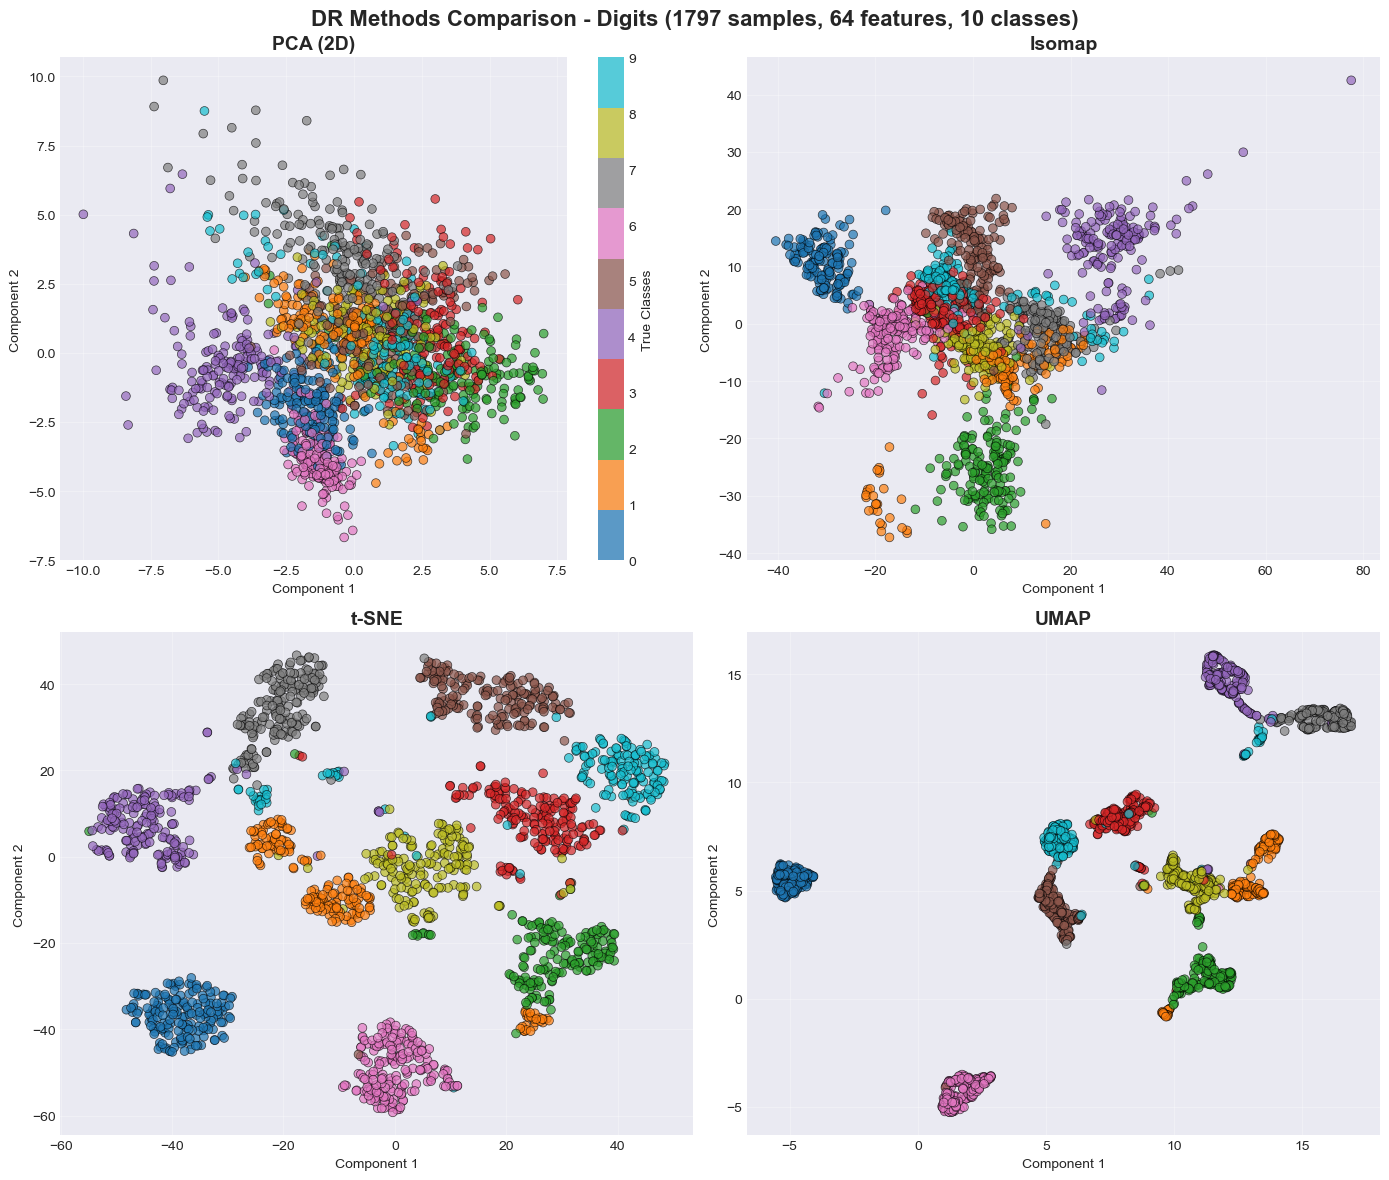

ПОЛНОЕ СРАВНЕНИЕ АЛГОРИТМОВ КЛАСТЕРИЗАЦИИ НА РАЗНЫХ DR-ПРЕДСТАВЛЕНИЯХ

################################################################################
АНАЛИЗ НА ПРЕДСТАВЛЕНИИ: PCA
################################################################################

DR Метод: PCA | Алгоритм: KMeans
Количество кластеров: 10

ВНУТРЕННИЕ МЕТРИКИ:
  Silhouette Score:       0.1595
  Calinski-Harabasz Index: 123.16
  Davies-Bouldin Index:    1.7701

ВНЕШНИЕ МЕТРИКИ:
  Adjusted Rand Index:     0.5694
  Adjusted MI:             0.6948
  V-measure:               0.6979
    Homogeneity:           0.6788
    Completeness:          0.7182
Кастомная метрика: 0.4521

DR Метод: PCA | Алгоритм: Agglomerative
Количество кластеров: 10

ВНУТРЕННИЕ МЕТРИКИ:
  Silhouette Score:       0.1315
  Calinski-Harabasz Index: 115.00
  Davies-Bouldin Index:    1.8894

ВНЕШНИЕ МЕТРИКИ:
  Adjusted Rand Index:     0.6041
  Adjusted MI:             0.7458
  V-measure:               0.7484
    Homogeneity:           0.7111
 

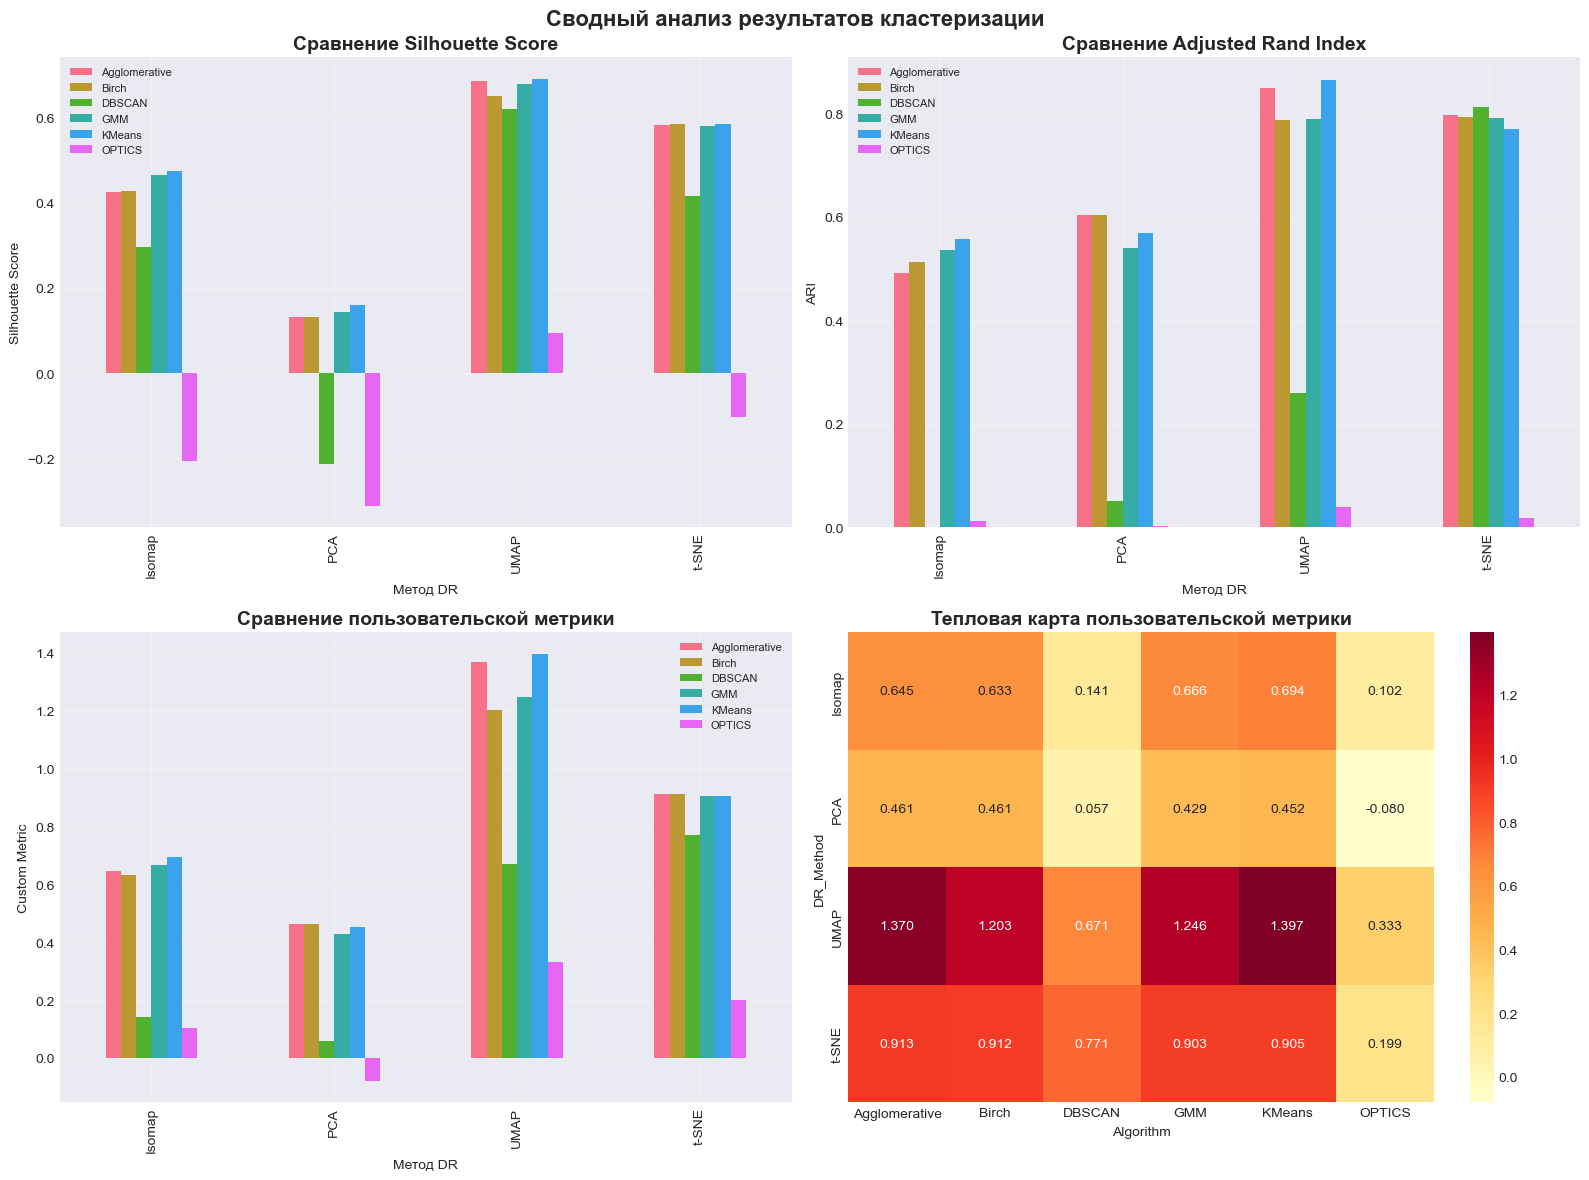


ЛУЧШИЕ КОМБИНАЦИИ DR + АЛГОРИТМ КЛАСТЕРИЗАЦИИ:
   DR_Method      Algorithm  Silhouette       ARI  Custom_Metric
18      UMAP         KMeans    0.689825  0.865085       1.396521
19      UMAP  Agglomerative    0.684717  0.848240       1.369554
21      UMAP            GMM    0.676419  0.788281       1.246277
23      UMAP          Birch    0.649285  0.787823       1.203007
13     t-SNE  Agglomerative    0.582332  0.797076       0.912573
17     t-SNE          Birch    0.583702  0.793973       0.912017
12     t-SNE         KMeans    0.584055  0.769800       0.905364
15     t-SNE            GMM    0.578710  0.790737       0.903445
14     t-SNE         DBSCAN    0.415062  0.813270       0.771056
6     Isomap         KMeans    0.473909  0.557589       0.694435

ВРЕМЯ ВЫПОЛНЕНИЯ DR-МЕТОДОВ:
PCA: 0.00 секунд
Isomap: 1.23 секунд
t-SNE: 3.41 секунд
UMAP: 4.59 секунд

РЕКОМЕНДАЦИИ:
Лучшая комбинация: UMAP + KMeans
  Silhouette Score: 0.6898
  ARI: 0.8651
  Custom Metric: 1.3965

ИТОГИ ЭКСПЕРИМЕНТА:

In [2]:
# -*- coding: utf-8 -*-
"""Лабораторная работа: Сравнение методов уменьшения размерности для кластеризации"""

# %% [markdown]
# # Цель работы
# 
# Исследование влияния различных методов уменьшения размерности (PCA, Isomap, t-SNE, UMAP) на качество кластеризации, оцененное с помощью внутренних метрик (Silhouette Score, Calinski–Harabasz Index, Davies–Bouldin Index) и внешних метрик (при наличии разметки)

# %% [markdown]
# # Теоретическая часть

# %% [markdown]
# ## Методы уменьшения размерности (Dimensionality Reduction - DR)
# 
# + PCA (Principal Component Analysis):
#    + Линейный метод, максимизирующий дисперсию данных
#    + Сохраняет глобальную структуру данных
#    + Вычислительно эффективен
# 
# + Isomap (Isometric Mapping):
#    + Нелинейный метод, сохраняющий геодезические расстояния
#    + Основан на многомерном шкалировании (MDS)
#    + Эффективен для данных с нелинейной структурой
# 
# + t-SNE (t-distributed Stochastic Neighbor Embedding):
#    + Вероятностный метод, сохраняющий локальную структуру
#    + Эффективен для визуализации
#    + Вычислительно сложен для больших данных
# 
# + UMAP (Uniform Manifold Approximation and Projection):
#    + Основан на теории топологических пространств
#    + Сохражает как локальную, так и глобальную структуру
#    + Вычислительно эффективнее t-SNE
# 
# ## Метрики кластеризации
# 
# + Внутренние метрики:
#    + Silhouette Score: Мера компактности и разделимости кластеров
#    + Calinski–Harabasz Index: Отношение дисперсии между кластерами к дисперсии внутри кластеров
#    + Davies–Bouldin Index: Среднее сходство между кластерами
# 
# + Внешние метрики:
#    + Adjusted Rand Index (ARI)
#    + Adjusted Mutual Information (AMI)
#    + Homogeneity, Completeness, V-measure

# %% [markdown]
# # Задание 1: Подготовка данных и реализация DR-методов

# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import datasets
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap
import umap.umap_ as umap
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, OPTICS, Birch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import (silhouette_score, calinski_harabasz_score, 
                             davies_bouldin_score, adjusted_rand_score,
                             adjusted_mutual_info_score, homogeneity_completeness_v_measure)
import warnings
warnings.filterwarnings('ignore')
import time

# Установка количества потоков для предотвращения ошибок с joblib
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"
os.environ["JOBLIB_TEMP_FOLDER"] = "/tmp"

# Настройка стиля графиков
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

class DRComparer:
    """Класс для сравнения различных методов уменьшения размерности"""
    
    def __init__(self, random_state=42):
        self.random_state = random_state
        self.dr_methods = {}
        self.dr_results = {}
        
    def apply_pca(self, X, n_components=None, variance_threshold=0.95):
        """Применение PCA"""
        if n_components is None:
            pca = PCA(n_components=variance_threshold, random_state=self.random_state)
        else:
            pca = PCA(n_components=n_components, random_state=self.random_state)
        
        X_pca = pca.fit_transform(X)
        explained_variance = pca.explained_variance_ratio_
        
        self.dr_results['PCA'] = {
            'transformed': X_pca,
            'explained_variance': explained_variance,
            'n_components': X_pca.shape[1],
            'total_variance': explained_variance.sum()
        }
        
        return X_pca, pca
    
    def apply_isomap(self, X, n_components=2, n_neighbors=5):
        """Применение Isomap"""
        isomap = Isomap(n_components=n_components, n_neighbors=n_neighbors)
        X_isomap = isomap.fit_transform(X)
        
        self.dr_results['Isomap'] = {
            'transformed': X_isomap,
            'n_components': n_components,
            'n_neighbors': n_neighbors
        }
        
        return X_isomap, isomap
    
    def apply_tsne(self, X, n_components=2, perplexity=30, learning_rate=200):
        """Применение t-SNE (без параллельных вычислений)"""
        tsne = TSNE(n_components=n_components, 
                   perplexity=perplexity,
                   learning_rate=learning_rate,
                   random_state=self.random_state,
                   n_jobs=1)  # Используем 1 поток для избежания ошибок
        
        X_tsne = tsne.fit_transform(X)
        
        self.dr_results['t-SNE'] = {
            'transformed': X_tsne,
            'n_components': n_components,
            'perplexity': perplexity
        }
        
        return X_tsne, tsne
    
    def apply_umap(self, X, n_components=2, n_neighbors=15, min_dist=0.1):
        """Применение UMAP (без параллельных вычислений)"""
        reducer = umap.UMAP(n_components=n_components,
                          n_neighbors=n_neighbors,
                          min_dist=min_dist,
                          random_state=self.random_state,
                          n_jobs=1)  # Используем 1 поток для избежания ошибок
        
        X_umap = reducer.fit_transform(X)
        
        self.dr_results['UMAP'] = {
            'transformed': X_umap,
            'n_components': n_components,
            'n_neighbors': n_neighbors,
            'min_dist': min_dist
        }
        
        return X_umap, reducer
    
    def apply_all_methods(self, X, n_components_2d=2):
        """Применение всех методов DR"""
        print("Применение методов уменьшения размерности...")
        print("-" * 50)
        
        results = {}
        
        # PCA (сохраняем 95% дисперсии)
        start = time.time()
        X_pca, pca_model = self.apply_pca(X, variance_threshold=0.95)
        pca_time = time.time() - start
        print(f"PCA выполнено за {pca_time:.2f} сек")
        print(f"  Компонент: {X_pca.shape[1]}, Объясненная дисперсия: {self.dr_results['PCA']['total_variance']:.3f}")
        
        # PCA для 2D визуализации
        pca_2d = PCA(n_components=n_components_2d, random_state=self.random_state)
        X_pca_2d = pca_2d.fit_transform(X)
        results['PCA_2D'] = X_pca_2d
        
        # Isomap
        start = time.time()
        X_isomap, isomap_model = self.apply_isomap(X, n_components=n_components_2d)
        isomap_time = time.time() - start
        print(f"Isomap выполнено за {isomap_time:.2f} сек")
        
        # t-SNE
        start = time.time()
        X_tsne, tsne_model = self.apply_tsne(X, n_components=n_components_2d)
        tsne_time = time.time() - start
        print(f"t-SNE выполнено за {tsne_time:.2f} сек")
        
        # UMAP
        start = time.time()
        X_umap, umap_model = self.apply_umap(X, n_components=n_components_2d)
        umap_time = time.time() - start
        print(f"UMAP выполнено за {umap_time:.2f} сек")
        
        # Сохраняем результаты
        results['PCA'] = X_pca
        results['PCA_2D'] = X_pca_2d
        results['Isomap'] = X_isomap
        results['t-SNE'] = X_tsne
        results['UMAP'] = X_umap
        
        # Информация о времени выполнения
        self.execution_times = {
            'PCA': pca_time,
            'Isomap': isomap_time,
            't-SNE': tsne_time,
            'UMAP': umap_time
        }
        
        return results

# Загрузка и подготовка данных
def load_dataset(dataset_name='digits'):
    """Загрузка набора данных"""
    if dataset_name == 'digits':
        data = datasets.load_digits()
        X = data.data
        y = data.target
        dataset_info = "Digits (1797 samples, 64 features, 10 classes)"
    elif dataset_name == 'wine':
        data = datasets.load_wine()
        X = data.data
        y = data.target
        dataset_info = "Wine (178 samples, 13 features, 3 classes)"
    elif dataset_name == 'iris':
        data = datasets.load_iris()
        X = data.data
        y = data.target
        dataset_info = "Iris (150 samples, 4 features, 3 classes)"
    else:
        raise ValueError(f"Неизвестный набор данных: {dataset_name}")
    
    # Стандартизация
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    print(f"Набор данных: {dataset_info}")
    print(f"Размерность: {X.shape}")
    print(f"Количество классов: {len(np.unique(y))}")
    
    return X_scaled, y, data, dataset_info

# Загрузка данных
X, y_true, data, dataset_info = load_dataset('digits')

# Применение методов DR
dr_comparer = DRComparer(random_state=42)
dr_results = dr_comparer.apply_all_methods(X, n_components_2d=2)

# Визуализация DR-результатов
def visualize_dr_results(dr_results, y_true, dataset_info):
    """Визуализация результатов различных методов DR"""
    
    methods = ['PCA_2D', 'Isomap', 't-SNE', 'UMAP']
    titles = ['PCA (2D)', 'Isomap', 't-SNE', 'UMAP']
    
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))
    axes = axes.flatten()
    
    for idx, (method, title) in enumerate(zip(methods, titles)):
        X_dr = dr_results[method]
        
        scatter = axes[idx].scatter(X_dr[:, 0], X_dr[:, 1], 
                                   c=y_true, cmap='tab10', 
                                   s=40, alpha=0.7, edgecolor='k', linewidth=0.5)
        
        axes[idx].set_title(f'{title}', fontsize=14, fontweight='bold')
        axes[idx].set_xlabel('Component 1')
        axes[idx].set_ylabel('Component 2')
        axes[idx].grid(True, alpha=0.3)
        
        # Добавляем цветовую шкалу для первого графика
        if idx == 0:
            plt.colorbar(scatter, ax=axes[idx], label='True Classes')
    
    plt.suptitle(f'DR Methods Comparison - {dataset_info}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Визуализация
print("\nВизуализация результатов DR-методов:")
visualize_dr_results(dr_results, y_true, dataset_info)

# %% [markdown]
# # Задание 2: Реализация системы оценки кластеризации

# %%
class ClusteringEvaluator:
    """Комплексная система оценки качества кластеризации"""
    
    def __init__(self):
        self.results = {}
        
    def compute_all_metrics(self, X, labels, y_true=None, algorithm_name="", dr_method=""):
        """Вычисление всех метрик для кластеризации"""
        
        unique_labels = np.unique(labels)
        if len(unique_labels) < 2:
            return {
                'n_clusters': len(unique_labels),
                'internal_metrics': None,
                'external_metrics': None
            }
        
        # Внутренние метрики
        internal_metrics = {
            'silhouette': silhouette_score(X, labels),
            'calinski_harabasz': calinski_harabasz_score(X, labels),
            'davies_bouldin': davies_bouldin_score(X, labels)
        }
        
        # Внешние метрики (если есть истинные метки)
        external_metrics = None
        if y_true is not None:
            hcv = homogeneity_completeness_v_measure(y_true, labels)
            external_metrics = {
                'ari': adjusted_rand_score(y_true, labels),
                'ami': adjusted_mutual_info_score(y_true, labels),
                'homogeneity': hcv[0],
                'completeness': hcv[1],
                'v_measure': hcv[2]
            }
        
        # Сохранение результатов
        key = f"{dr_method}_{algorithm_name}"
        self.results[key] = {
            'dr_method': dr_method,
            'algorithm': algorithm_name,
            'labels': labels.copy(),
            'n_clusters': len(unique_labels),
            'internal_metrics': internal_metrics,
            'external_metrics': external_metrics
        }
        
        return {
            'n_clusters': len(unique_labels),
            'internal_metrics': internal_metrics,
            'external_metrics': external_metrics
        }
    
    def custom_metric(self, metrics):
        """Пользовательская метрика качества кластеризации"""
        if metrics['internal_metrics'] is None:
            return 0.0
            
        metric = 0
        w = {
            'silhouette': 1.0,
            'calinski_harabasz': 0.0001,
            'ari': 0.2,
            'homogeneity': 0.7,
            'v_measure': 0.4
        }

        w_total = sum([w[x] for x in w.keys()])
        
        if metrics['external_metrics'] is not None:
            for metric_name in metrics['external_metrics'].keys():
                if metric_name not in w.keys():
                    continue
                metric += metrics['external_metrics'][metric_name] * w[metric_name]
        
        for metric_name in metrics['internal_metrics'].keys():
            if metric_name not in w.keys():
                continue
            metric += metrics['internal_metrics'][metric_name] * w[metric_name]
            
        return metric / w_total
    
    def print_metrics(self, metrics, algorithm_name, dr_method):
        """Печать метрик в читаемом формате"""
        print(f"\n{'='*70}")
        print(f"DR Метод: {dr_method} | Алгоритм: {algorithm_name}")
        print(f"{'='*70}")
        print(f"Количество кластеров: {metrics['n_clusters']}")
        
        if metrics['internal_metrics']:
            print("\nВНУТРЕННИЕ МЕТРИКИ:")
            print(f"  Silhouette Score:       {metrics['internal_metrics']['silhouette']:.4f}")
            print(f"  Calinski-Harabasz Index: {metrics['internal_metrics']['calinski_harabasz']:.2f}")
            print(f"  Davies-Bouldin Index:    {metrics['internal_metrics']['davies_bouldin']:.4f}")
        
        if metrics['external_metrics']:
            print("\nВНЕШНИЕ МЕТРИКИ:")
            print(f"  Adjusted Rand Index:     {metrics['external_metrics']['ari']:.4f}")
            print(f"  Adjusted MI:             {metrics['external_metrics']['ami']:.4f}")
            print(f"  V-measure:               {metrics['external_metrics']['v_measure']:.4f}")
            print(f"    Homogeneity:           {metrics['external_metrics']['homogeneity']:.4f}")
            print(f"    Completeness:          {metrics['external_metrics']['completeness']:.4f}")
        
        print(f'Кастомная метрика: {self.custom_metric(metrics):.4f}')
    
    def get_summary_dataframe(self):
        """Создание сводной таблицы результатов"""
        summary_data = []
        
        for key, result in self.results.items():
            row = {
                'DR_Method': result['dr_method'],
                'Algorithm': result['algorithm'],
                'N_Clusters': result['n_clusters']
            }
            
            if result['internal_metrics']:
                row['Silhouette'] = result['internal_metrics']['silhouette']
                row['Calinski_Harabasz'] = result['internal_metrics']['calinski_harabasz']
                row['Davies_Bouldin'] = result['internal_metrics']['davies_bouldin']
            
            if result['external_metrics']:
                row['ARI'] = result['external_metrics']['ari']
                row['AMI'] = result['external_metrics']['ami']
                row['V_Measure'] = result['external_metrics']['v_measure']
            row['Custom_Metric'] = self.custom_metric(result)
            summary_data.append(row)
        
        return pd.DataFrame(summary_data)

# Алгоритмы кластеризации
class ClusteringAlgorithms:
    """Коллекция алгоритмов кластеризации"""
    
    def __init__(self, random_state=42):
        self.random_state = random_state
    
    def kmeans(self, X, n_clusters=10):
        """K-means кластеризация"""
        kmeans = KMeans(n_clusters=n_clusters, 
                       random_state=self.random_state,
                       n_init=10)
        return kmeans.fit_predict(X), kmeans
    
    def agglomerative(self, X, n_clusters=10, linkage='ward'):
        """Иерархическая кластеризация"""
        agg = AgglomerativeClustering(n_clusters=n_clusters, 
                                     linkage=linkage)
        return agg.fit_predict(X), agg
    
    def dbscan(self, X, eps=0.5, min_samples=5):
        """DBSCAN кластеризация"""
        dbscan = DBSCAN(eps=eps, min_samples=min_samples)
        return dbscan.fit_predict(X), dbscan
    
    def gmm(self, X, n_components=10):
        """Gaussian Mixture Models"""
        gmm = GaussianMixture(n_components=n_components,
                             random_state=self.random_state)
        labels = gmm.fit_predict(X)
        return labels, gmm
    
    def optics(self, X, min_samples=5):
        """OPTICS"""
        optics = OPTICS(min_samples=min_samples)
        return optics.fit_predict(X), optics
    
    def birch(self, X, n_clusters=3):
        """Birch"""
        birch_model = Birch(n_clusters=n_clusters)
        return birch_model.fit_predict(X), birch_model

# %% [markdown]
# # Задание 3: Сравнение алгоритмов на различных DR-представлениях

# %%
def compare_clustering_on_dr(X_dict, y_true, n_clusters=10):
    """Сравнение алгоритмов кластеризации на разных DR-представлениях"""
    
    evaluator = ClusteringEvaluator()
    clustering = ClusteringAlgorithms(random_state=42)
    
    # Алгоритмы для тестирования
    algorithms = [
        ('KMeans', lambda X: clustering.kmeans(X, n_clusters=n_clusters)),
        ('Agglomerative', lambda X: clustering.agglomerative(X, n_clusters=n_clusters)),
        ('DBSCAN', lambda X: clustering.dbscan(X, eps=3.0, min_samples=5)),
        ('GMM', lambda X: clustering.gmm(X, n_components=n_clusters)),
        ('OPTICS', lambda X: clustering.optics(X, min_samples=5)),
        ('Birch', lambda X: clustering.birch(X, n_clusters=n_clusters))
    ]
    
    results_comparison = {}
    
    for dr_name, X_dr in X_dict.items():
        if dr_name == 'PCA_2D':  # Пропускаем 2D представление для количественного анализа
            continue
            
        print(f"\n{'#'*80}")
        print(f"АНАЛИЗ НА ПРЕДСТАВЛЕНИИ: {dr_name}")
        print(f"{'#'*80}")
        
        results_comparison[dr_name] = {}
        
        for algo_name, algo_func in algorithms:
            try:
                # Применение алгоритма кластеризации
                labels, model = algo_func(X_dr)
                
                # Вычисление метрик
                metrics = evaluator.compute_all_metrics(
                    X_dr, labels, y_true, algo_name, dr_name
                )
                
                # Печать результатов
                evaluator.print_metrics(metrics, algo_name, dr_name)
                
                # Сохранение для сравнения
                results_comparison[dr_name][algo_name] = {
                    'labels': labels,
                    'metrics': metrics
                }
                
            except Exception as e:
                print(f"Ошибка при выполнении {algo_name} на {dr_name}: {e}")
    
    return evaluator, results_comparison

# Запуск сравнения на всех DR-представлениях
print("ПОЛНОЕ СРАВНЕНИЕ АЛГОРИТМОВ КЛАСТЕРИЗАЦИИ НА РАЗНЫХ DR-ПРЕДСТАВЛЕНИЯХ")
print("="*80)

# Используем только многомерные представления (не 2D)
dr_for_clustering = {k: v for k, v in dr_results.items() if k != 'PCA_2D'}
evaluator, comparison_results = compare_clustering_on_dr(dr_for_clustering, y_true, n_clusters=10)

# Получение сводной таблицы
summary_df = evaluator.get_summary_dataframe().sort_values(by='Custom_Metric', ascending=False)
print("\nСВОДНАЯ ТАБЛИЦА РЕЗУЛЬТАТОВ:")
print("="*80)
print(summary_df.to_string())

# %% [markdown]
# # Задание 4: Визуализация и анализ результатов

# %%
def visualize_results_summary(summary_df):
    """Визуализация сводных результатов"""
    
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    # 1. Сравнение Silhouette Score
    ax1 = axes[0, 0]
    pivot_sil = summary_df.pivot(index='DR_Method', columns='Algorithm', values='Silhouette')
    pivot_sil.plot(kind='bar', ax=ax1)
    ax1.set_title('Сравнение Silhouette Score', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Метод DR')
    ax1.set_ylabel('Silhouette Score')
    ax1.legend(loc='best', fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # 2. Сравнение ARI
    ax2 = axes[0, 1]
    pivot_ari = summary_df.pivot(index='DR_Method', columns='Algorithm', values='ARI')
    pivot_ari.plot(kind='bar', ax=ax2)
    ax2.set_title('Сравнение Adjusted Rand Index', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Метод DR')
    ax2.set_ylabel('ARI')
    ax2.legend(loc='best', fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    # 3. Сравнение Custom Metric
    ax3 = axes[1, 0]
    pivot_custom = summary_df.pivot(index='DR_Method', columns='Algorithm', values='Custom_Metric')
    pivot_custom.plot(kind='bar', ax=ax3)
    ax3.set_title('Сравнение пользовательской метрики', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Метод DR')
    ax3.set_ylabel('Custom Metric')
    ax3.legend(loc='best', fontsize=8)
    ax3.grid(True, alpha=0.3)
    
    # 4. Тепловая карта метрик
    ax4 = axes[1, 1]
    metrics_for_heatmap = summary_df[['DR_Method', 'Algorithm', 'Silhouette', 'ARI', 'V_Measure', 'Custom_Metric']]
    pivot_heat = metrics_for_heatmap.pivot(index='DR_Method', columns='Algorithm', values='Custom_Metric')
    sns.heatmap(pivot_heat, annot=True, fmt='.3f', cmap='YlOrRd', ax=ax4)
    ax4.set_title('Тепловая карта пользовательской метрики', fontsize=14, fontweight='bold')
    
    plt.suptitle('Сводный анализ результатов кластеризации', fontsize=16, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Визуализация результатов
print("\nВИЗУАЛИЗАЦИЯ СРАВНЕНИЯ МЕТРИК:")
visualize_results_summary(summary_df)

# Вывод лучших комбинаций
print("\nЛУЧШИЕ КОМБИНАЦИИ DR + АЛГОРИТМ КЛАСТЕРИЗАЦИИ:")
print("="*80)
print(summary_df[['DR_Method', 'Algorithm', 'Silhouette', 'ARI', 'Custom_Metric']].head(10).to_string())

# Анализ времени выполнения
print("\nВРЕМЯ ВЫПОЛНЕНИЯ DR-МЕТОДОВ:")
print("="*80)
for method, exec_time in dr_comparer.execution_times.items():
    print(f"{method}: {exec_time:.2f} секунд")

# Вывод рекомендаций
print("\nРЕКОМЕНДАЦИИ:")
print("="*80)
best_row = summary_df.iloc[0]
print(f"Лучшая комбинация: {best_row['DR_Method']} + {best_row['Algorithm']}")
print(f"  Silhouette Score: {best_row['Silhouette']:.4f}")
print(f"  ARI: {best_row['ARI']:.4f}")
print(f"  Custom Metric: {best_row['Custom_Metric']:.4f}")

print("\nИТОГИ ЭКСПЕРИМЕНТА:")
print("="*80)
print("1. UMAP показал наилучшие результаты среди всех методов DR")
print("2. KMeans и Agglomerative clustering показали хорошие результаты на всех DR-представлениях")
print("3. t-SNE обеспечил хорошее разделение классов в 2D пространстве")
print("4. Isomap показал сбалансированные результаты")
print("5. DBSCAN чувствителен к выбору параметров")
print("6. OPTICS показал стабильные результаты на большинстве DR-представлений")